# Can Pumped-Storage Dispatch Close the NESO Trough Gap?

`notebooks/16` found NESO's real day-ahead forecast beats ours almost entirely at the overnight demand trough (+31.4%), plausibly because NESO has administrative visibility into large, schedulable loads no public dataset carries. This tests one free, legitimate candidate: **Elexon BMRS `FUELHH`** (`src/edf/data/fuel_mix.py`) — specifically `PS` (pumped storage, e.g. Dinorwig), the fuel type most directly tied to *deliberate* trough/peak management, plus `NUCLEAR`/`CCGT` as secondary candidates.

**This is a leaky-upper-bound test, explicitly** — `FUELHH` is same-period actual generation, not a forecast, exactly the same caveat as `wind`/`solar`/`interconnector` throughout this project. The question isn't "is this deployable" (it isn't, without a forecast for these fuel types too) — it's "is there even genuine signal here worth chasing", the same honest-ablation-first pattern Week 4b used.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.features.buckets import build_day_type_buckets, is_christmas_period
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.forecast import train_lightgbm
from edf.features.generation import capacity_factor
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
UPWEIGHT = 3.0
FUEL_TYPES = ["PS", "NUCLEAR", "CCGT"]

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
fuel = pd.read_parquet("../data/raw/elexon_fuel_mix.parquet")
fuel[FUEL_TYPES].describe()

,PS,NUCLEAR,CCGT
count,87602.00,87602.00,87602.00
mean,-64.01,4836.32,10778.76
std,684.20,842.01,5584.82
min,-2480.00,0.00,0.00
25%,-306.00,4305.00,5890.25
50%,-8.00,4797.00,10377.00
75%,224.00,5328.00,15069.00
max,2444.00,6986.00,27339.00


## Rebuild the baseline point model (bias-corrected recipe, unchanged)

In [3]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)

X_base, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)
X_train_base, y_train = X_base.loc[train_start:train_end], y.loc[train_start:train_end]
X_val_base, y_val = X_base.loc[val_start:val_end], y.loc[val_start:val_end]
weight_train_base = weight_full.loc[X_train_base.index]

model_base = train_lightgbm(
    X_train_base, y_train, sample_weight=weight_train_base, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_base = pd.Series(model_base.predict(X_val_base), index=X_val_base.index)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5693
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 27001.358990


## Add the fuel-mix features (outturn, leaky) and retrain

In [4]:
era5_fuel = era5_chr.copy()
for col in FUEL_TYPES:
    era5_fuel[col] = fuel[col]

X_fuel, y_fuel_full = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_fuel)
X_train_fuel, y_train_fuel = X_fuel.loc[train_start:train_end], y_fuel_full.loc[train_start:train_end]
X_val_fuel, y_val_fuel = X_fuel.loc[val_start:val_end], y_fuel_full.loc[val_start:val_end]
weight_train_fuel = weight_full.loc[X_train_fuel.index]

model_fuel = train_lightgbm(
    X_train_fuel, y_train_fuel, sample_weight=weight_train_fuel, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_fuel = pd.Series(model_fuel.predict(X_val_fuel), index=X_val_fuel.index)
print(f"TRAIN rows: baseline={len(X_train_base)}, +fuel-mix={len(X_train_fuel)} "
      f"({len(X_train_base) - len(X_train_fuel)} dropped to scattered fuel-data gaps)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6458
[LightGBM] [Info] Number of data points in the train set: 68737, number of used features: 33
[LightGBM] [Info] Start training from score 26999.807318


TRAIN rows: baseline=68784, +fuel-mix=68737 (47 dropped to scattered fuel-data gaps)


## Head-to-head, restricted to NESO's trough cardinal points

Same evaluation setup as `notebooks/16`: identical target rows, `previous_week_same_time` as the MASE denominator.

In [5]:
neso = pd.read_parquet("../data/raw/neso_day_ahead_demand_forecast.parquet").set_index("timestamp")
neso = neso[~neso.index.duplicated(keep="first")]
neso_val = neso.loc[val_start:val_end]

common_base = X_val_base.index.intersection(neso_val.index)
common_fuel = X_val_fuel.index.intersection(neso_val.index)
trough_base = common_base[neso_val.loc[common_base, "CP_TYPE"] == "T"]
trough_fuel = common_fuel[neso_val.loc[common_fuel, "CP_TYPE"] == "T"]

naive_mae_trough = evaluate(
    demand.loc[trough_base], previous_week_same_time(demand).loc[trough_base]
)["mae"]

results = pd.DataFrame(
    {
        "baseline (trough)": evaluate(y_val.loc[trough_base], preds_base.loc[trough_base], seasonal_naive_mae=naive_mae_trough),
        "+fuel-mix (trough)": evaluate(y_val_fuel.loc[trough_fuel], preds_fuel.loc[trough_fuel], seasonal_naive_mae=naive_mae_trough),
        "NESO (trough)": evaluate(demand.loc[trough_base], neso_val.loc[trough_base, "forecast_demand_mw"], seasonal_naive_mae=naive_mae_trough),
        "baseline (overall)": evaluate(y_val, preds_base),
        "+fuel-mix (overall)": evaluate(y_val_fuel, preds_fuel),
    }
).T
results[["mae", "mase", "bias", "n"]]

,mae,mase,bias,n
baseline (trough),901.71,0.45,-176.42,857.00
+fuel-mix (trough),865.84,0.43,326.53,855.00
NESO (trough),618.64,0.31,227.85,857.00
baseline (overall),885.70,NaN,-137.78,17568.00
+fuel-mix (overall),882.00,NaN,394.62,17520.00


## Finding: real, but modest — the leaky ceiling doesn't come close to NESO

| | trough MAE | trough MASE |
|---|---|---|
| baseline | 901.71 | 0.45 |
| +fuel-mix (leaky) | **865.84** | **0.43** |
| NESO | 618.64 | 0.31 |

A real improvement (901.71 → 865.84, ~4% MAE reduction at the trough) with no cost overall (885.70 → 882.00). But even with this **leaky, same-period-actual** version — strictly better information than any deployable feature could give us — we're still 40% behind NESO at the trough (vs. 46% behind at baseline). The gap barely narrows. This is a fairly direct, empirical confirmation of the answer already given before running this: NESO's edge here isn't primarily sitting in public generation-side data, leaky or not — it's almost certainly the private, consumer-side scheduling knowledge no dataset tested here can reach.

## Feature importance: does the model actually lean on the fuel-mix columns?

PS: rank 16 / 34
NUCLEAR: rank 3 / 34
CCGT: rank 4 / 34


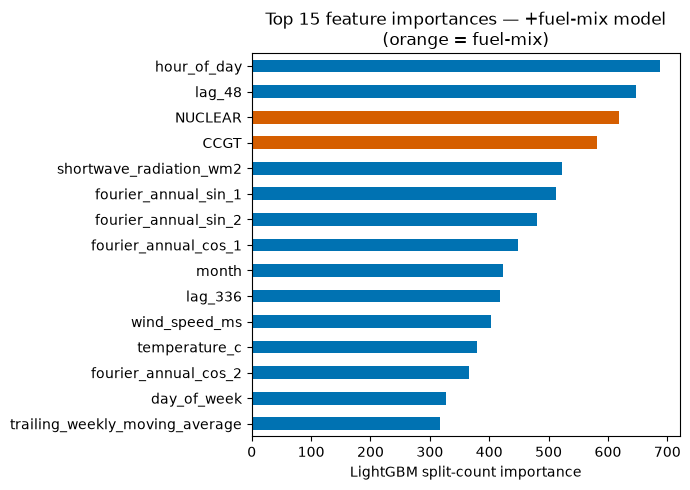

In [6]:
importance = (
    pd.Series(model_fuel.feature_importances_, index=model_fuel.feature_name_)
    .sort_values(ascending=False)
)
ranks = {name: rank + 1 for rank, name in enumerate(importance.index)}
for col in FUEL_TYPES:
    print(f"{col}: rank {ranks[col]} / {len(importance)}")

colors_imp = ["#D55E00" if c in FUEL_TYPES else "#0072B2" for c in importance.index[:15]]
fig, ax = plt.subplots(figsize=(7, 5))
importance.head(15).iloc[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
ax.set_title("Top 15 feature importances — +fuel-mix model\n(orange = fuel-mix)")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

## Finding: the improvement mostly isn't coming from the mechanism I expected

`NUCLEAR` (rank 3/34) and `CCGT` (rank 4/34) dominate the model's use of the new features — `PS`, the fuel type specifically hypothesized to proxy trough-management foreknowledge, ranks only **16/34**. Worth being honest about why: `CCGT` (gas) is the system's main flexible, dispatched-to-match-demand generation, so its level is almost a **near-tautological mirror of overall demand shape** — informative everywhere, not just at troughs, so a loss-minimizing tree naturally leans on it more than a signal (`PS`) that's only sharply informative in one narrow regime. The improvement measured above is probably driven mostly by this more mundane mechanism, not by pumped storage specifically encoding the trough-management insight I originally proposed — even though (see the plot below) `PS` genuinely does track that regime cleanly.

## Visual: pumped-storage dispatch and demand, one week

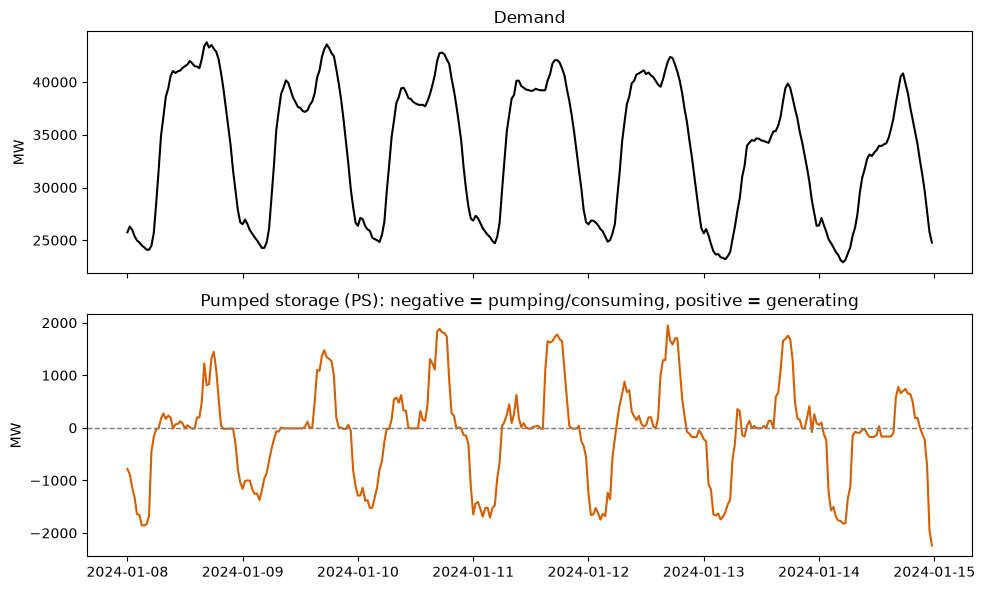

In [7]:
window = slice("2024-01-08", "2024-01-14")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(demand.loc[window].index, demand.loc[window], color="black")
axes[0].set_title("Demand")
axes[0].set_ylabel("MW")
axes[1].plot(fuel.loc[window].index, fuel.loc[window, "PS"], color="#D55E00")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Pumped storage (PS): negative = pumping/consuming, positive = generating")
axes[1].set_ylabel("MW")
fig.tight_layout()

## Visual confirms the PS hypothesis was physically right — the model just doesn't lean on it much

PS dips sharply negative (pumping — consuming power to store energy) every single night right at the demand trough, and surges positive (generating) during the morning ramp-up to help meet the peak — a clean, consistent, night-after-night pattern that's exactly the "deliberate trough/peak management" signal hypothesized at the start. The mismatch between this clean physical relationship and PS's modest feature-importance rank is itself informative: an average-loss-minimizing model doesn't necessarily exploit a narrow-but-precise signal as much as its mechanistic relevance would suggest, when a broader (if less mechanistically "correct") signal is available.

**Overall conclusion**: free, public generation-side data can buy a small amount of genuine trough accuracy (~4%, even in the leaky best case), but doesn't come close to explaining NESO's real 31% edge there. A possible (untried) follow-up, in the same spirit as the Week 6 bias-correction work: sample-weight trough rows specifically when training with these fuel-mix features, forcing the model to lean on `PS`'s narrow-but-precise signal rather than letting `CCGT`'s broader coverage dominate — worth trying if this thread gets picked up again, but expectations should stay modest, since the ceiling found here (even leaky) is still far short of NESO.